In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/regression_sprint/regression_sprint_data_1.csv', index_col=0)
df.head(10)

,ZAR/USD,Value of Exports (ZAR)
2008M01,7.01,39356.82
2008M02,7.66,46946.33
2008M03,7.97,51150.89
2008M04,7.79,56174.34
2008M05,7.62,56240.45
2008M06,7.92,60159.93
2008M07,7.63,61268.16
2008M08,7.66,60390.94
2008M09,8.06,61067.34
2008M10,9.74,65652.57


In [5]:
from sklearn.model_selection import train_test_split

In [11]:
y = df['ZAR/USD']
X = df.drop('ZAR/USD', axis=1)

Capital is used for independent data that could contain a table of features. Lowercase is used for dependent data since we are predicting a single thing that is in one column.

Axis = 1. This tells pandas to look horizontally across column headers

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

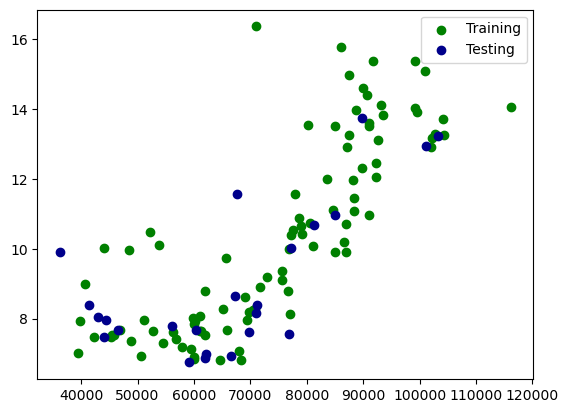

In [13]:
plt.scatter(X_train, y_train, label = 'Training', color  = 'green')
plt.scatter(X_test, y_test, label  = 'Testing', color  = 'darkblue')
plt.legend()
plt.show()

In [15]:
#fitting our model and exposing it only to training data
from sklearn.linear_model import LinearRegression

#declare model object
dm  = LinearRegression()

#fit the model
dm.fit(X_train, y_train)

#extract y intercept and slope
a  = float(dm.intercept_)

b  = dm.coef_

print("Slope:\t\t", b)
print("Intercept:\t", float(a))


Slope:		 [0.0001199]
Intercept:	 1.4542630444144784


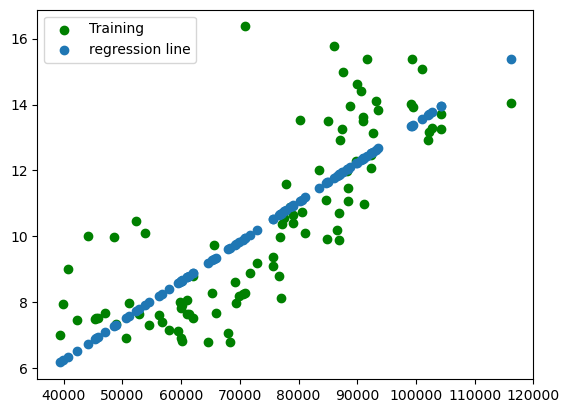

In [16]:
#assess the model
#predictions
gen_y = dm.predict(X_train)
#plot training data
plt.scatter(X_train, y_train, label = 'Training', color  = 'green')
#plot regression line
plt.scatter(X_train, gen_y, label = 'regression line')
plt.legend()
plt.show()


In [17]:
from sklearn import metrics


In [18]:
print("Training: ")
#calculate mse
print("MSE: ", metrics.mean_squared_error(y_train, gen_y))
print("R-squared: ", metrics.r2_score(y_train, gen_y))

Training: 
MSE:  2.612547537558907
R-squared:  0.6402293095045937


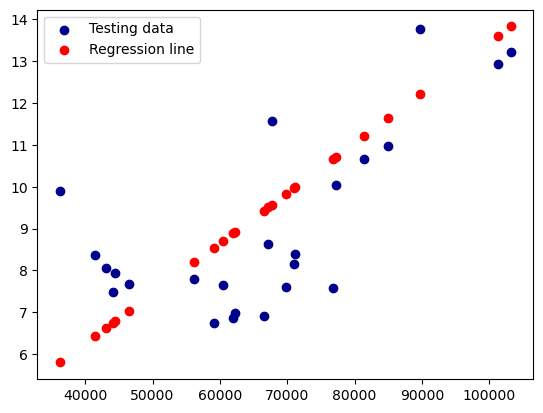

In [19]:
#assessment based on unseen data
gen_y_test = dm.predict(X_test)

plt.scatter(X_test, y_test, color = 'darkblue', label = 'Testing data')
plt.scatter(X_test, gen_y_test, color ='red', label = 'Regression line')
plt.legend()
plt.show()

In [20]:
print("Testing")
print("MSE: ", metrics.mean_squared_error(y_test, gen_y_test))
print("R squared:", metrics.r2_score(y_test, gen_y_test))
      

Testing
MSE:  3.038981977599917
R squared: 0.3003104341257886
